In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print(train.shape, test.shape)
train.head()

(630000, 13) (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
train.isnull().sum().sort_values(ascending = False)

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [4]:
train.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [5]:
##映射有序变量
sleep_map = {"poor":0, "average":1, "good":2}
facility_map = {"low":0, "medium":1, "high":2}
difficulty_map = {"easy":0, "moderate":1, "hard":2}

train["sleep_quality"] = train["sleep_quality"].map(sleep_map)
train["facility_rating"] = train["facility_rating"].map(facility_map)
train["exam_difficulty"] = train["exam_difficulty"].map(difficulty_map)

test["sleep_quality"] = test["sleep_quality"].map(sleep_map)
test["facility_rating"] = test["facility_rating"].map(facility_map)
test["exam_difficulty"] = test["exam_difficulty"].map(difficulty_map)

##映射二元变量
internet_map = {"no":0, "yes":1}
train["internet_access"] = train["internet_access"].map(internet_map)
test["internet_access"] = test["internet_access"].map(internet_map)


<Axes: >

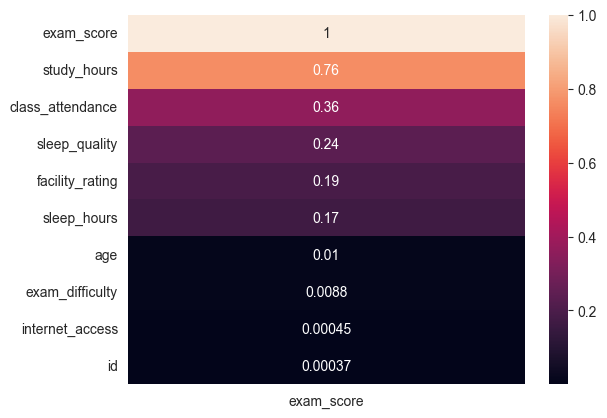

In [6]:
corr_matrix = train.corr(numeric_only = True)
sns.heatmap(corr_matrix[['exam_score']].sort_values(by = 'exam_score', ascending = False), annot = True)

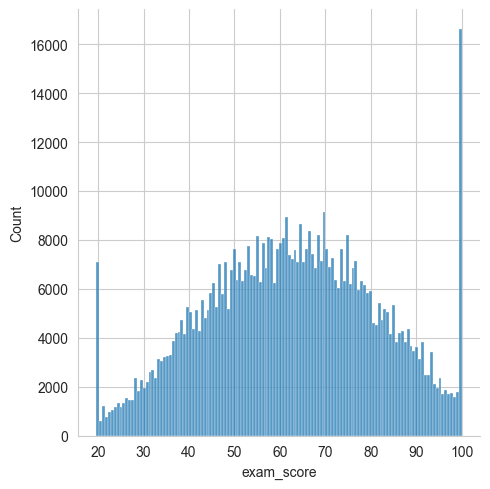

In [7]:
sns.displot(train['exam_score'])
plt.show()

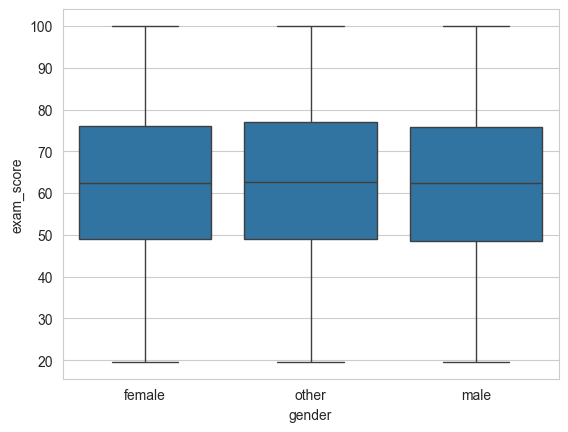

In [8]:
sns.boxplot(x="gender", y="exam_score", data=train)
plt.show()

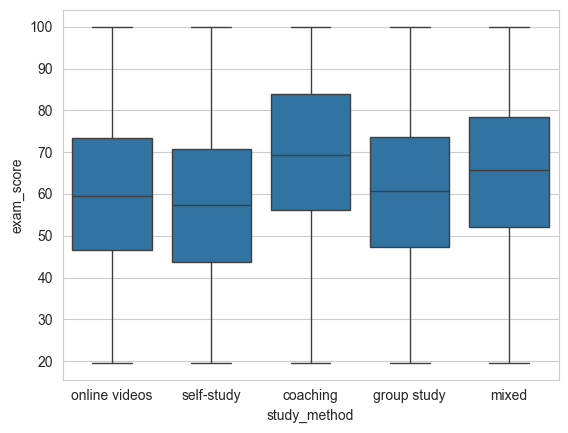

In [9]:
sns.boxplot(x="study_method", y="exam_score", data=train)
plt.show()

In [10]:
##特征工程
df = pd.get_dummies(train, columns = ["gender", "course", "study_method"], drop_first = True)

In [11]:
train["study_efficiency"] = train["study_hours"] * train["class_attendance"]
train["sleep_intensity"] = train["sleep_hours"] * train["sleep_quality"]
train["study_intensity"] = train["study_hours"] / (train["sleep_hours"] + 1)

In [12]:
##Prepare data
X = df.drop("exam_score", axis = 1)
y = df["exam_score"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [14]:
## Baseline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_val)

print("MSE:", mean_squared_error(y_val, pred))
print("R2:", r2_score(y_val, pred))

MSE: 78.97886390966124
R2: 0.7779291562919042


In [15]:
## RondomForest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("MSE:", mean_squared_error(y_val, pred))
print("R2:", r2_score(y_val, pred))

MSE: 83.45679626256783
R2: 0.7653382152926111


随机森林误差变大了，准确性变低了。而且模型跑太久了

In [16]:
## LightGBM
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("MSE:", mean_squared_error(y_val, pred))
print("R2:", r2_score(y_val, pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003982 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 859
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 21
[LightGBM] [Info] Start training from score 62.482335
MSE: 77.24539327665707
R2: 0.7828032867485637


In [17]:
test["study_efficiency"] = test["study_hours"] * test["class_attendance"]
test["sleep_intensity"] = test["sleep_hours"] * test["sleep_quality"]
test["study_intensity"] = test["study_hours"] / (test["sleep_hours"] + 1)

In [18]:
test = pd.get_dummies(test)

test = test.reindex(columns = X.columns, fill_value = 0)

pred = model.predict(test)

test_id = test["id"]

submission = pd.DataFrame({
    "id": test_id,
    "exam_score":pred
})

submission.to_csv("submission.csv", index = False)